In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# add path to utils/
from pathlib import Path
import sys

project_root = Path().resolve().parent
sys.path.append(str(project_root))

# import functions from utils/
from utils.importance_sampling import *
from utils.utility import *
from utils.rejection_sampling import *

from scipy.stats import uniform, norm, cauchy

In [ ]:
# start:  9:47pm
# end:   10:47pm
#            1hr

n_samples = 100_000

In [7]:
#q1
x = np.random.uniform(0, 3, n_samples)
y = np.random.uniform(0, 3, n_samples)
z = np.random.uniform(0, 3, n_samples)

f = np.exp(np.sin(x * y + y * z**2))

vals = f * (3 - 0)**3
generate_mean_and_std_err(vals)

Mean: 38.3164
Standard Error: 0.0704


In [8]:
# q2
x = np.random.normal(0, 1, n_samples)
y = np.random.normal(0, 1, n_samples)
z = np.random.normal(0, 1, n_samples)

indicators = np.abs(x / y)**2 > z**2
generate_mean_and_std_err(indicators, prob=True)

Mean: 0.6283
Standard Error: 0.0015


In [11]:
# q3
n_samples = 100_000
x = np.random.uniform(0, 2, n_samples)
y = np.random.uniform(0, 2, n_samples)
z = np.random.uniform(0, 2, n_samples)

rate = np.mean((x < y) * (y < z))
vol = rate * (2 - 0)**3

print(vol)

1.32376


In [102]:
# q4
n_samples = 10_000
rolls_needed = []
for i in range(n_samples):
    roll_sum = 0
    count = 0
    while True:
        roll = np.random.randint(low=1, high=7)
        roll_sum += roll
        count += 1
        if roll_sum > 20:
            rolls_needed.append(count)
            break

generate_mean_and_std_err(rolls_needed)
# 6.47

Mean: 6.4820
Standard Error: 0.0126


10000 / 100000 samples accepted.
20000 / 100000 samples accepted.
30000 / 100000 samples accepted.
40000 / 100000 samples accepted.
50000 / 100000 samples accepted.
60000 / 100000 samples accepted.
70000 / 100000 samples accepted.
80000 / 100000 samples accepted.
90000 / 100000 samples accepted.
100000 / 100000 samples accepted.
Acceptance Rate: 0.4881


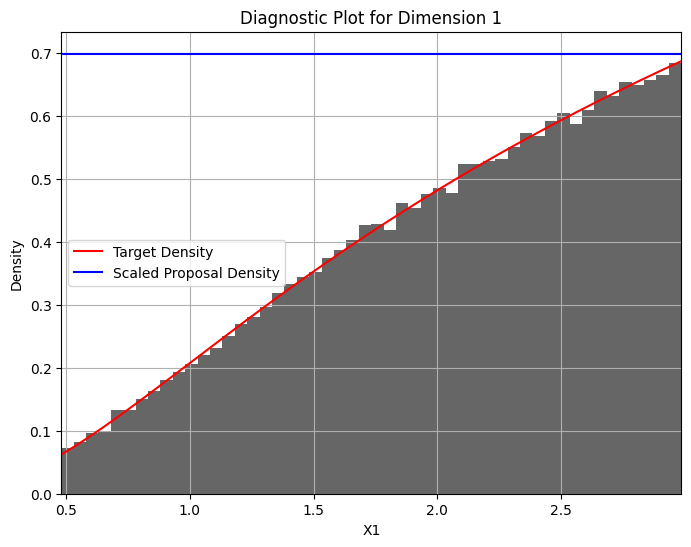

Mean: 2.0583
Standard Error: 0.0021


In [ ]:
# q5
target_density = lambda x: np.log(1 + x**2)
proposal_density = lambda x: uniform.pdf(x, loc=0, scale=3)
proposal_rvs = lambda: np.random.uniform(0, 3, size=(1,1))
M_init = 7.0

samples, acceptance_rate = rejection_sampling(
    target_density,
    proposal_density,
    proposal_rvs,
    M_init,
    n_samples,
    diagnostics=True,
)

generate_mean_and_std_err(samples)

In [ ]:
# q6
std_dev_est = np.std(samples)
print(std_dev_est)

0.652038264236924


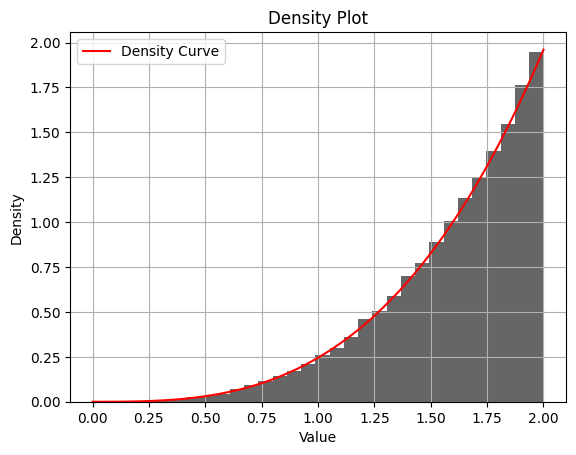

np.float64(2.4715633583206467)

In [35]:
# q7
n_samples = 50_000
target_pdf = lambda x: x**3 # on [0, 2]
target_cdf = lambda x: 1/16 * x**4
target_inv_cdf = lambda u: (16 * u)**(0.25)

xx = np.linspace(0, 2, 100)
yy = target_pdf(xx)

u = np.random.uniform(0, 1, n_samples)
samples = target_inv_cdf(u)

plot_density(
    samples,
    target_pdf,
    x_min=0,
    x_max=2.0
)

np.mean(target_inv_cdf(u) * target_inv_cdf(1 - u))



In [ ]:
# q8
indicators = samples > 1.8
generate_mean_and_std_err(indicators, prob=True)
# No simulation needed: from the cdf
1 - target_cdf(1.8)

Mean: 0.3475
Standard Error: 0.0021


In [108]:
# q9
n_samples = 100_000
z = np.random.normal(0, 1, n_samples)
normalizing_constant = np.sqrt(2 * np.pi)

samples = np.log(1 + z**2) * normalizing_constant

generate_mean_and_std_err(samples)


Mean: 1.3375
Standard Error: 0.0041


In [111]:
# q10
normalizing_constant = np.pi**(2) # careful to do pi^2 not pi^-2
x = np.random.standard_cauchy(n_samples)
y = np.random.standard_cauchy(n_samples)

samples = np.sin(3 * x**2 + 2 * y**2) * normalizing_constant
generate_mean_and_std_err(samples)

Mean: 1.0710
Standard Error: 0.0217


In [39]:
# q11
k = 10
exps = np.random.exponential(scale=1, size=(n_samples, k))
completion_times = np.max(exps, axis=1)
indicators = completion_times > 4
generate_mean_and_std_err(indicators, prob=True)


Mean: 0.1708
Standard Error: 0.0017


In [ ]:
# q12
x = np.random.normal(0, 1, n_samples)
y = np.random.normal(0, 1, n_samples)

samples = x * y
generate_mean_and_std_err(samples)
# 0

Mean: 0.0046
Standard Error: 0.0045


In [ ]:
# q13
condition = x + y > 1

samples = x[condition] * y[condition]
generate_mean_and_std_err(samples)

Mean: 0.4525
Standard Error: 0.0098


In [54]:
# q14
n_samples = 1_000_000
x = np.random.normal(0, 5, n_samples)
y = np.random.normal(0, 5, n_samples)

ratios = norm.pdf(x) * norm.pdf(y) / norm.pdf(x, loc=0, scale=5) / norm.pdf(y, loc=0, scale=5)

samples = 10**10 * (x**2 + y**2 > 40) * ratios
generate_mean_and_std_err(samples)



Mean: 20.6170
Standard Error: 0.1078


In [55]:
# q15
k = 12
uniforms = np.random.uniform(-0.5, 0.5, size=(n_samples, k))
indicators = np.sum(uniforms, axis=1) > 0.5
generate_mean_and_std_err(indicators, prob=True)

Mean: 0.3103
Standard Error: 0.0005


In [57]:
1 - norm.cdf(0.5)

np.float64(0.3085375387259869)

In [ ]:
# q16
# 0

In [118]:
# q17
target_density = lambda x: x[0]**2 + x[1]**2 + x[2]**2
proposal_density = lambda x: 1
proposal_rvs = lambda : np.random.uniform(-2, 2, size=(3,))
M_init = 12

samples, acceptance_rate = rejection_sampling(
    target_density,
    proposal_density,
    proposal_rvs,
    M_init,
    n_samples=100_000
)

samples = np.sum(samples**2, axis=1)
generate_mean_and_std_err(samples)


10000 / 100000 samples accepted.
20000 / 100000 samples accepted.
30000 / 100000 samples accepted.
40000 / 100000 samples accepted.
50000 / 100000 samples accepted.
60000 / 100000 samples accepted.
70000 / 100000 samples accepted.
80000 / 100000 samples accepted.
90000 / 100000 samples accepted.
100000 / 100000 samples accepted.
Mean: 5.0762
Standard Error: 0.0063


In [91]:
# q18
t = 50
choices = np.random.choice([-1, 1], size=(n_samples, t), p=[0.5, 0.5])
paths = np.hstack([np.zeros((n_samples, 1)), np.cumsum(choices, axis=1)])

L = np.sum(paths == 0, axis=1)
generate_mean_and_std_err(L)


Mean: 5.7255
Standard Error: 0.0037


In [92]:
# q19
std_dev_L = np.std(L)
print(std_dev_L)

3.6759922156609637


In [100]:
# q20
k = 5
points = np.random.uniform(0, 2 * np.pi, size=(n_samples, 5))
points = np.sort(points, axis=1)
rolled_points = np.roll(points, shift=1, axis=1)
diffs = points - rolled_points

# distances between adjacent points on the circumference
diffs[:, 0] += 2 * np.pi

# check if greater than pi
indicators = np.any(diffs > np.pi, axis=1)
generate_mean_and_std_err(indicators)

Mean: 0.3126
Standard Error: 0.0005
